In [114]:
using LinearAlgebra
using Plots
using QuadGK
using FastGaussQuadrature
using LaTeXStrings
using ProgressMeter
using Dierckx
using Interpolations
using LsqFit
pgfplotsx() # pgfplotsx() or gr()
default(
    fontfamily = "Computer Modern",
    tickfont   = font(15, "Computer Modern"),
    guidefont  = font(15, "Computer Modern"),
    legendfont = font(15, "Computer Modern"),
    lw = 2,
    grid = :on,
    gridalpha = 0.3,
    size = (500, 400),
    legend = :topright,
    framestyle = :box,
    color_palette = palette(:tab10)
)
const address = "/Users/johnreeg/Documents/Repositories/Maris-Tandy/images/";

In [115]:
# Constants
const Nf = 4.0
const m = 0.0037
const w = 0.16
const D = 0.93 # 0.93312
const Lambda2 = 1e6
const epsilon2 = 1e-4
const Lambda_PV = 2e2
const Lambda_QCD = 0.234
const gamma_m = 0.48 # 12/(33 - 2 * Nf) = 0.48
const mu = 19.0
Z_2 = 1
Z_4m = 0.7 * m;

### Part 1 - Solving $A(p^2)$, $B(p^2)$ for real Momenta

In [116]:
# Integration Grids
x, w_x = gausslegendre(200)
z, w_z = gausschebyshevu(200) # Chebyshev second kind

t = 0.5 * (log(Lambda2) - log(epsilon2)) * x .+ 0.5 * (log(Lambda2) + log(epsilon2))
w_t = 0.5 * (log(Lambda2) - log(epsilon2)) * w_x

# Initial Vectors
A = 1.6 * ones(length(t))
B = (m + 1e-3) * ones(length(t));

In [117]:
# # Integration Grids
# x, w_x = gausslegendre(100)
# z, w_z = gausslegendre(20) # Chebyshev second kind

# z1  = 0.5 * z .- 0.5
# z2  = 0.5 * z .+ 0.5
# w_z = 0.5 * w_z

# t = 0.5 * (log(Lambda2) - log(epsilon2)) * x .+ 0.5 * (log(Lambda2) + log(epsilon2))
# w_t = 0.5 * (log(Lambda2) - log(epsilon2)) * w_x

# # Initial Vectors
# A = 1.6 * ones(length(t))
# B = (m + 1e-3) * ones(length(t));

In [118]:
# Dot Products
pk(p, q, z) = p^2 - p*q*z
qk(p, q, z) = p*q*z - q^2
k2(p, q, z) = p^2 + q^2 - 2*p*q*z

# Stephan called them alpha(k^2)
F_UV(k2) = 2pi * gamma_m * (1 - exp(-k2)) / log(exp(2) - 1 + (1 + k2 / Lambda_QCD^2)^2)
G(k2) = D/w^6 * pi * k2^2 * exp(-k2 / w^2) + F_UV(k2)

# Angular Integrals over z = cos(psi)
function z_intA(p, q)
    K2 = k2.(p, q, z)
    integrand = @. w_z * ( p*q*z + 2*pk(p, q, z)*qk(p, q, z)/K2 ) * G(K2) / K2 # * Lambda_PV^2 / (K2 + Lambda_PV^2)
    return sum(integrand)
end

function z_intB(p, q)
    K2 = k2.(p, q, z)
    integrand = @. w_z * G(K2) / K2 # * Lambda_PV^2 / (K2 + Lambda_PV^2)
    return sum(integrand)
end;

In [119]:
# # Dot Products
# pk(p, q, z) = p^2 - p*q*z
# qk(p, q, z) = p*q*z - q^2
# k2(p, q, z) = p^2 + q^2 - 2*p*q*z

# # Stephan called them alpha(k^2)
# F_UV(k2) = 2pi * gamma_m * (1 - exp(-k2)) / log(exp(2) - 1 + (1 + k2 / Lambda_QCD^2)^2)
# G(k2) = D/w^6 * pi * k2^2 * exp(-k2 / w^2) + F_UV(k2)

# # Angular Integrals over z = cos(psi)
# function z_intA(p, q)
#     K1 = k2.(p, q, z1)
#     K2 = k2.(p, q, z2)
#     integrand1 = @. w_z * sqrt(1-z1^2) * ( p*q*z1 + 2*pk(p, q, z1)*qk(p, q, z1)/K1 ) * G(K1) / K1 # * Lambda_PV^2 / (K1 + Lambda_PV^2)
#     integrand2 = @. w_z * sqrt(1-z2^2) * ( p*q*z2 + 2*pk(p, q, z2)*qk(p, q, z2)/K2 ) * G(K2) / K2 # * Lambda_PV^2 / (K2 + Lambda_PV^2)
#     return sum(integrand1) + sum(integrand2)
# end

# function z_intB(p, q)
#     K1 = k2.(p, q, z1)
#     K2 = k2.(p, q, z2)
#     integrand1 = @. w_z * sqrt(1-z1^2) * G(K1) / K1 # * Lambda_PV^2 / (K1 + Lambda_PV^2)
#     integrand2 = @. w_z * sqrt(1-z2^2) * G(K2) / K2 # * Lambda_PV^2 / (K2 + Lambda_PV^2)
#     return sum(integrand1) + sum(integrand2)
# end;

In [120]:
# Final Radial Integrals
function Sigma_A(p2, A, B, Z_2)
    integrand = @. w_t * exp(2*t) * A / (exp(t) * A^2 + B^2) * z_intA(sqrt(p2), exp(t/2))
    return Z_2^2 * 16pi/(3*(2pi)^3 * p2) * sum(integrand)
end

function Sigma_B(p2, A, B, Z_2)
    integrand = @. w_t * exp(2*t) * B / (exp(t) * A^2 + B^2) * z_intB(sqrt(p2), exp(t/2))
    return Z_2^2 * 16pi/(2pi)^3 * sum(integrand)
end;

In [121]:
# Iteration Step Function
function update(A, B, Z_2, Z_4m)
    A_int = Z_2 .+ Sigma_A.(exp.(t), Ref(A), Ref(B), Z_2)
    B_int = Z_4m .+ Sigma_B.(exp.(t), Ref(A), Ref(B), Z_2)
    max_A = maximum(abs.(A .- A_int))
    max_B = maximum(abs.(B .- B_int))
    Z_2  = 1 - Sigma_A(mu^2, A, B, Z_2)
    Z_4m = m - Sigma_B(mu^2, A, B, Z_2)
    # alpha = 0.5
    # return alpha .* A_int .+ (1-alpha) .* A, alpha .* B_int .+ (1-alpha) .* B, max(max_A, max_B)
    return A_int, B_int, Z_2, Z_4m, max(max_A, max_B)
end;

In [122]:
# Iteration Loop
max_iter = 100
p = Progress(max_iter, desc = "Berechne...")

for i in 1:max_iter
    A, B, Z_2, Z_4m, max_error = update(A, B, Z_2, Z_4m)
    next!(p)
    if max_error < 1e-8
        println("Finished: i = ", i)
        break
    end
    if i == max_iter
        throw(error("Failed: max_error = ", max_error))
    end
end

Berechne...  83%|█████████████████████████████████▎      |  ETA: 0:00:12

Finished: i = 83


In [123]:
# # Plots
# plot(exp.(t), A, xaxis=:log10, xlims = (epsilon2, Lambda2), ylims = (0, 2.4), yticks = 0.4:0.4:2.4, label = L"A(p^2)", xlabel = L"p^2")
# plot!(exp.(t), B, label = L"B(p^2)")
# plot!(exp.(t), B./A, label = L"M(p^2)")
# savefig(address * "D1.pdf"); plot!()
# plot!()

### Part 2 - Finding a Fitting Function

In [124]:
fitter(x, p) = @. p[1] .+ (p[2] - p[1]) ./ (1 .+ exp.(-p[3] .* (x .- p[4]))).^(1 / p[5]) - p[6] * x
par_A = curve_fit(fitter, t, A, [2.24, 1.,     1.27, -0.01, 1.1,  0.001  ]).param
par_B = curve_fit(fitter, t, B, [1.28, 0.0035, 2.5,  -0.58, 2.54, 0.00026]).param;

In [125]:
println("max. abs. err. A: ", maximum(abs.(A - fitter(t, par_A))))
println("max. rel. err. A: ", maximum(abs.(A - fitter(t, par_A)) ./ A))
println("max. abs. err. B: ", maximum(abs.(B - fitter(t, par_B))))
println("max. rel. err. B: ", maximum(abs.(B - fitter(t, par_B)) ./ B))

max. abs. err. A: 0.007939231854229067
max. rel. err. A: 0.006408666858026111
max. abs. err. B: 0.005255104107901171
max. rel. err. B: 0.30735671455865166


In [126]:
A_itp = Spline1D(t, A, k = 3);
B_itp = Spline1D(t, B, k = 3);
# A_itp(x) = @. par_A[1] .+ (par_A[2] - par_A[1]) ./ (1 .+ exp.(-par_A[3] .* (x .- par_A[4]))).^(1 / par_A[5]) - par_A[6] * x;
# B_itp(x) = @. par_B[1] .+ (par_B[2] - par_B[1]) ./ (1 .+ exp.(-par_B[3] .* (x .- par_B[4]))).^(1 / par_B[5]) - par_B[6] * x;

In [127]:
# plot(exp.(t), A, xaxis=:log10, xlims = (epsilon2, Lambda2), ylims = (0, 2.4), yticks = 0.4:0.4:2.4, label = L"A(p^2)", xlabel = L"p^2")
# plot!(exp.(t), B, label = L"B(p^2)")
# plot!(exp.(t), A_itp(t), label = L"A_{fit}")
# plot!(exp.(t), A_itp(t), label = L"B_{fit}")

In [128]:
# plot(exp.(t), abs.(A - A_itp(t)) ./ A, xaxis=:log10, xlims = (epsilon2, Lambda2), yaxis=:log10, label = L"A_{rel}", xlabel = L"p^2")
# plot!(exp.(t), abs.(B - B_itp(t)) ./ B, label = L"B_{rel}")

### Part 3 - Integrating with Complex Momenta

In [129]:
# Integration Grids
x, w_x = gausslegendre(100)
z, w_z = gausslegendre(30) # Chebyshev second kind

z1  = 0.5 * z .- 0.5
z2  = 0.5 * z .+ 0.5
w_z = 0.5 * w_z;

In [130]:
# Angular Integrals over z = cos(psi)
function z_intA(p, q)
    K1 = k2.(p, q, z1)
    K2 = k2.(p, q, z2)
    integrand1 = @. w_z * sqrt(1-z1^2) * ( p*q*z1 + 2*pk(p, q, z1)*qk(p, q, z1)/K1 ) * G(K1) / K1 # * Lambda_PV^2 / (K1 + Lambda_PV^2)
    integrand2 = @. w_z * sqrt(1-z2^2) * ( p*q*z2 + 2*pk(p, q, z2)*qk(p, q, z2)/K2 ) * G(K2) / K2 # * Lambda_PV^2 / (K2 + Lambda_PV^2)
    return sum(integrand1) + sum(integrand2)
end

function z_intB(p, q)
    K1 = k2.(p, q, z1)
    K2 = k2.(p, q, z2)
    integrand1 = @. w_z * sqrt(1-z1^2) * G(K1) / K1 # * Lambda_PV^2 / (K1 + Lambda_PV^2)
    integrand2 = @. w_z * sqrt(1-z2^2) * G(K2) / K2 # * Lambda_PV^2 / (K2 + Lambda_PV^2)
    return sum(integrand1) + sum(integrand2)
end;

In [225]:
function Z_intA(p, q)
    integrand(z) = sqrt(1 - z^2) * ( p*q*z + 2*pk(p, q, z)*qk(p, q, z)/k2(p, q, z) ) * G(k2(p, q, z)) / k2(p, q, z) # * Lambda_PV^2 / (k2(p, q, z) + Lambda_PV^2)
    return quadgk(integrand, -1, 0, 1)[1]
end

function Z_intB(p, q)
    integrand(z) = sqrt(1 - z^2) * G(k2(p, q, z)) / k2(p, q, z) # * Lambda_PV^2 / (k2(p, q, z) + Lambda_PV^2)
    return quadgk(integrand, -1, 0, 1)[1]
end;

In [226]:
G(k2(1im, 1, -1e-9)) / k2(1im, 1, -1e-9)

1.5079644737503113 + 0.0003482840821224597im

In [227]:
Z_intB(1im, 1)

486.71964997588304 - 5.009326287108706e-13im

In [112]:
function Sigma_A(p2)
    integrand(t) = exp(2*t) * A_itp(t) / (exp(t) * A_itp(t)^2 + B_itp(t)^2) * Z_intA(sqrt(p2), exp(t/2))
    return Z_2^2 * 16pi/(3*(2pi)^3 * p2) * quadgk(integrand, log(epsilon2), log(abs(p2)), log(Lambda2), rtol = 1e-9, order = 10)[1]
end

function Sigma_B(p2)
    integrand(t) = exp(2*t) * B_itp(t) / (exp(t) * A_itp(t)^2 + B_itp(t)^2) * Z_intB(sqrt(p2), exp(t/2))
    return Z_2^2 * 16pi/(2pi)^3 * quadgk(integrand, log(epsilon2), log(abs(p2)), log(Lambda2), rtol = 1e-9, order = 10)[1]
end;

In [113]:
Z_2 + Sigma_A(Complex(-1))

LoadError: InterruptException:

In [109]:
# Plots
p2 = Complex.(-10 : 0.2 : -0.04)

AA = Z_2 .+ Sigma_A.(p2)
BB = Z_4m .+ Sigma_B.(p2)
MM = abs.(BB./AA)
mask = isfinite.(MM) .& (MM .< 1e4);

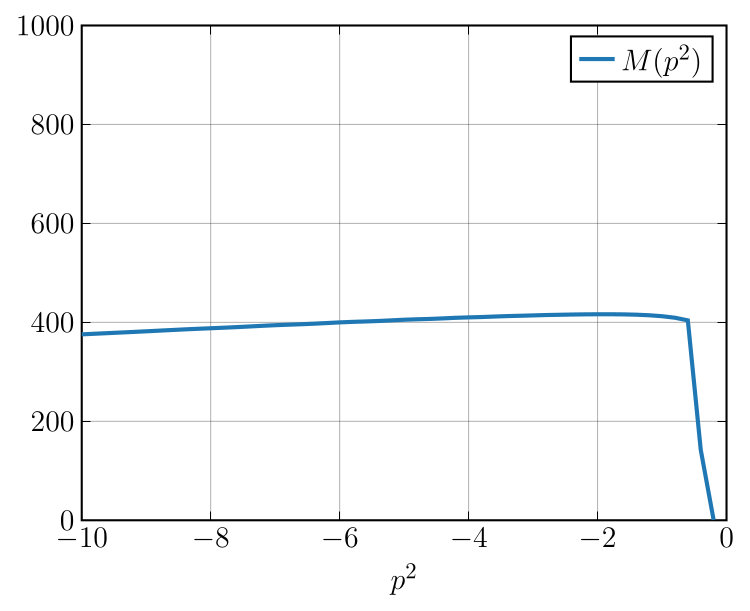

In [110]:
plot(real.(p2)[mask], MM[mask], xlims = (-10, 0), ylims = (0, 1000), label = L"M(p^2)", xlabel = L"p^2") # \; \left[\mathrm{GeV}^2\right]
# plot!(p2, real.(BB), label = L"B(p^2)")
# plot!(p2, real.(AA), label = L"A(p^2)")
# savefig(address * "$(length(t))_$(length(z)).pdf")
# plot!()